In [18]:
# ============================================================
# SUPERSTORE DATA CLEANING, VISUALIZATION & ANALYSIS PROJECT
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# ------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("SuperStoreOrders.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

First 5 rows:
          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage          

In [20]:
# ------------------------------------------------------------
# 3. DATA CLEANING
# ------------------------------------------------------------

# Convert column names to lowercase and replace spaces
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nCleaned Column Names:")
print(df.columns)


# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())


# Remove duplicate rows
df = df.drop_duplicates()



Cleaned Column Names:
Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

Missing Values:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

Duplicate Rows:
0


In [21]:
# ------------------------------------------------------------
# 4. HANDLE DATE COLUMNS
# ------------------------------------------------------------

df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

df["ship_date"] = pd.to_datetime(
    df["ship_date"],
    errors="coerce"
)


# Create additional date columns

df["order_year"] = df["order_date"].dt.year

df["order_month"] = df["order_date"].dt.month

df["order_month_name"] = df["order_date"].dt.month_name()

df["order_year_month"] = (
    df["order_date"]
    .dt.to_period("M")
    .astype(str)
)


In [22]:
# ------------------------------------------------------------
# 5. CHECK DATA TYPES
# ------------------------------------------------------------

print("\nData Types:")
print(df.dtypes)



Data Types:
order_id                    object
order_date          datetime64[ns]
ship_date           datetime64[ns]
ship_mode                   object
customer_name               object
segment                     object
state                       object
country                     object
market                      object
region                      object
product_id                  object
category                    object
sub_category                object
product_name                object
sales                       object
quantity                     int64
discount                   float64
profit                     float64
shipping_cost              float64
order_priority              object
year                         int64
order_year                 float64
order_month                float64
order_month_name            object
order_year_month            object
dtype: object


In [23]:
# ------------------------------------------------------------
# 6. HANDLE NUMERIC COLUMNS
# ------------------------------------------------------------

numeric_columns = [
    "sales",
    "quantity",
    "discount",
    "profit",
    "shipping_cost"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# Fill missing numerical values with median

for column in numeric_columns:

    if df[column].isnull().sum() > 0:

        df[column] = df[column].fillna(
            df[column].median()
        )


In [24]:
# ------------------------------------------------------------
# 7. HANDLE TEXT COLUMNS
# ------------------------------------------------------------

text_columns = df.select_dtypes(
    include="object"
).columns

for column in text_columns:

    df[column] = df[column].astype(str).str.strip()

In [25]:
# ------------------------------------------------------------
# 8. BASIC DATA INFORMATION
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())


print("\nStatistical Summary:")
print(df.describe())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          51290 non-null  object        
 1   order_date        20067 non-null  datetime64[ns]
 2   ship_date         19834 non-null  datetime64[ns]
 3   ship_mode         51290 non-null  object        
 4   customer_name     51290 non-null  object        
 5   segment           51290 non-null  object        
 6   state             51290 non-null  object        
 7   country           51290 non-null  object        
 8   market            51290 non-null  object        
 9   region            51290 non-null  object        
 10  product_id        51290 non-null  object        
 11  category          51290 non-null  object        
 12  sub_category      51290 non-null  object        
 13  product_name      51290 non-null  object        
 14  

In [26]:
# ------------------------------------------------------------
# 9. BUSINESS ANALYSIS
# ------------------------------------------------------------

# Total Sales

total_sales = df["sales"].sum()

print("\nTotal Sales:")
print(total_sales)


# Total Profit

total_profit = df["profit"].sum()

print("\nTotal Profit:")
print(total_profit)


# Total Quantity

total_quantity = df["quantity"].sum()

print("\nTotal Quantity Sold:")
print(total_quantity)


# Number of Orders

total_orders = df["order_id"].nunique()

print("\nTotal Orders:")
print(total_orders)


# Profit Margin

profit_margin = (
    total_profit / total_sales
) * 100

print("\nProfit Margin:")
print(round(profit_margin, 2), "%")


Total Sales:
8037638.0

Total Profit:
1469034.82128

Total Quantity Sold:
178312

Total Orders:
25035

Profit Margin:
18.28 %


In [27]:
# ------------------------------------------------------------
# 10. SALES BY CATEGORY
# ------------------------------------------------------------

category_sales = (
    df.groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nSales by Category:")
print(category_sales)



Sales by Category:
category
Office Supplies    2831607.0
Technology         2724736.0
Furniture          2481295.0
Name: sales, dtype: float64


In [28]:
# ------------------------------------------------------------
# 11. PROFIT BY CATEGORY
# ------------------------------------------------------------

category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

print("\nProfit by Category:")
print(category_profit)


Profit by Category:
category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64


In [29]:
# ------------------------------------------------------------
# 12. SALES BY REGION
# ------------------------------------------------------------

region_sales = (
    df.groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nSales by Region:")
print(region_sales)


Sales by Region:
region
Central           1850836.0
South             1054586.0
North              810951.0
Oceania            644555.0
EMEA               586188.0
Africa             548818.0
Southeast Asia     547803.0
North Asia         470395.0
West               436493.0
Central Asia       403443.0
East               377503.0
Caribbean          255060.0
Canada              51007.0
Name: sales, dtype: float64


In [30]:
# ------------------------------------------------------------
# 13. PROFIT BY REGION
# ------------------------------------------------------------

region_profit = (
    df.groupby("region")["profit"]
    .sum()
    .sort_values(ascending=False)
)

print("\nProfit by Region:")
print(region_profit)


Profit by Region:
region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           121666.64200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: profit, dtype: float64


In [31]:
# ------------------------------------------------------------
# 14. TOP 10 CUSTOMERS
# ------------------------------------------------------------

top_customers = (
    df.groupby("customer_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Customers:")
print(top_customers)



Top 10 Customers:
customer_name
Eric Murdock        19951.0
John Grady          19637.0
Maria Etezadi       18545.0
Theone Pippenger    17724.0
Ben Ferrer          16969.0
Muhammed Yedwab     16784.0
Randy Bradley       16707.0
Dan Reichenbach     16705.0
Mathew Reese        16433.0
Steven Ward         16369.0
Name: sales, dtype: float64


In [32]:
# ------------------------------------------------------------
# 15. MONTHLY SALES
# ------------------------------------------------------------

monthly_sales = (
    df.groupby("order_year_month")["sales"]
    .sum()
)

print("\nMonthly Sales:")
print(monthly_sales)



Monthly Sales:
order_year_month
2011-01      52054.0
2011-02      55632.0
2011-03      53021.0
2011-04      40729.0
2011-05      37790.0
2011-06      42739.0
2011-07      54504.0
2011-08      52492.0
2011-09      46606.0
2011-10      45376.0
2011-11      42620.0
2011-12      42270.0
2012-01      47299.0
2012-02      58136.0
2012-03      57657.0
2012-04      47687.0
2012-05      64855.0
2012-06      52441.0
2012-07      63370.0
2012-08      47429.0
2012-09      52477.0
2012-10      56443.0
2012-11      55201.0
2012-12      54974.0
2013-01      66851.0
2013-02      60225.0
2013-03      63740.0
2013-04      77346.0
2013-05      72288.0
2013-06      81903.0
2013-07      68681.0
2013-08      67690.0
2013-09      69804.0
2013-10      69338.0
2013-11      92096.0
2013-12      77524.0
2014-01      69172.0
2014-02      87753.0
2014-03     100958.0
2014-04      98734.0
2014-05      75957.0
2014-06      87819.0
2014-07      85782.0
2014-08      91198.0
2014-09      78459.0
2014-10      93540.0
2

In [33]:
# ------------------------------------------------------------
# 16. DATA VISUALIZATION
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

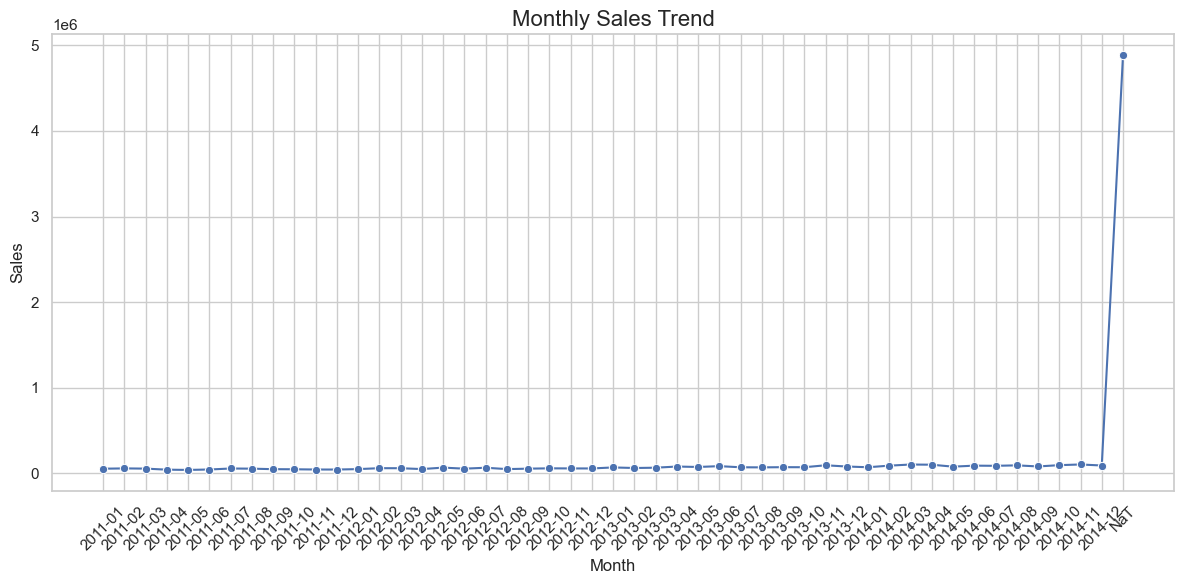

In [34]:
# ------------------------------------------------------------
# CHART 1: MONTHLY SALES TREND
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

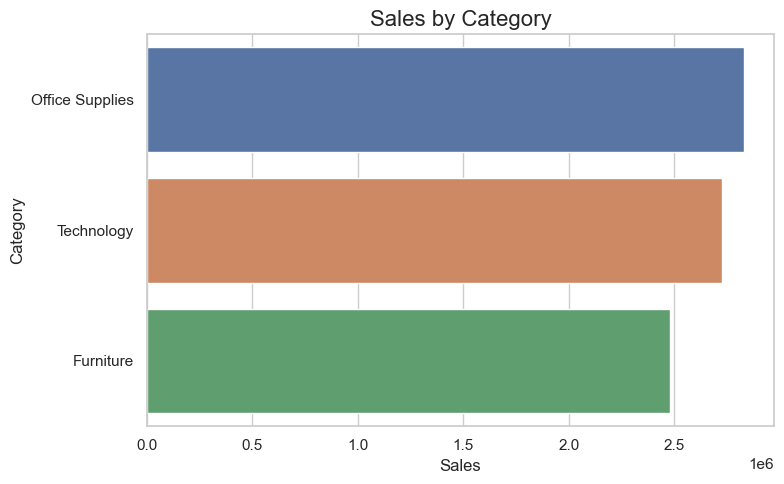

In [35]:
# ------------------------------------------------------------
# CHART 2: SALES BY CATEGORY
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index,
    hue=category_sales.index,
    legend=False
)

plt.title(
    "Sales by Category",
    fontsize=16
)

plt.xlabel("Sales")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

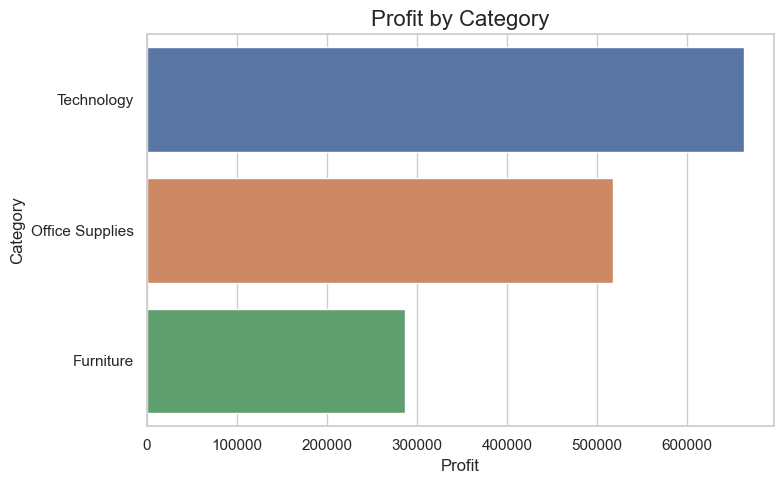

In [36]:
# ------------------------------------------------------------
# CHART 3: PROFIT BY CATEGORY
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_profit.values,
    y=category_profit.index,
    hue=category_profit.index,
    legend=False
)

plt.title(
    "Profit by Category",
    fontsize=16
)

plt.xlabel("Profit")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

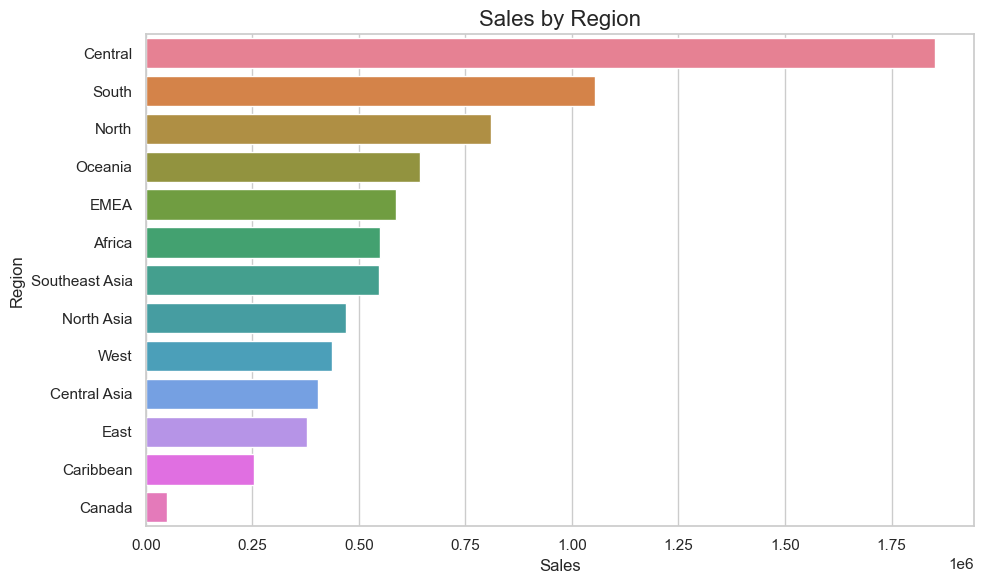

In [37]:
# ------------------------------------------------------------
# CHART 4: SALES BY REGION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    hue=region_sales.index,
    legend=False
)

plt.title(
    "Sales by Region",
    fontsize=16
)

plt.xlabel("Sales")

plt.ylabel("Region")

plt.tight_layout()

plt.show()

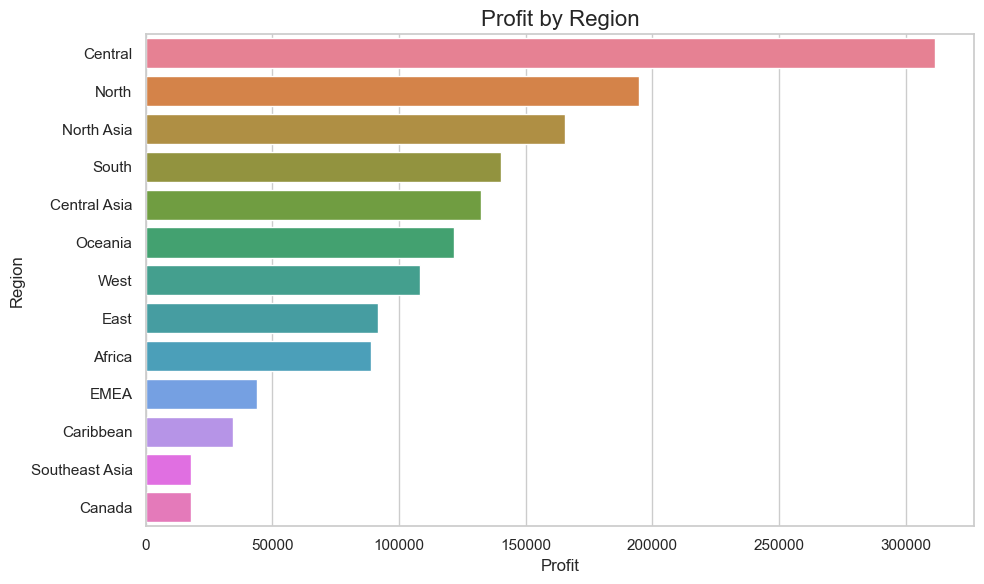

In [38]:
# ------------------------------------------------------------
# CHART 5: PROFIT BY REGION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_profit.values,
    y=region_profit.index,
    hue=region_profit.index,
    legend=False
)

plt.title(
    "Profit by Region",
    fontsize=16
)

plt.xlabel("Profit")

plt.ylabel("Region")

plt.tight_layout()

plt.show()

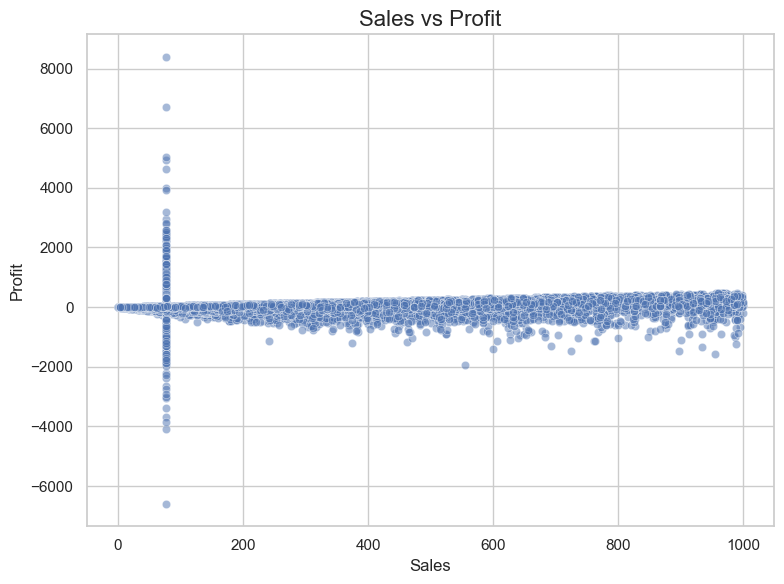

In [39]:
# ------------------------------------------------------------
# CHART 6: SALES VS PROFIT
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="sales",
    y="profit",
    alpha=0.5
)

plt.title(
    "Sales vs Profit",
    fontsize=16
)

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.tight_layout()

plt.show()

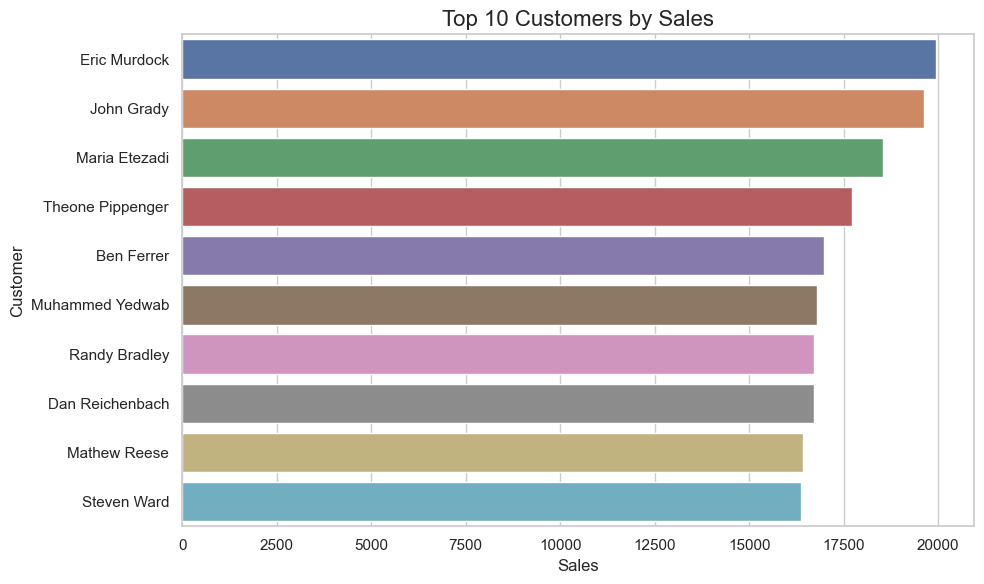

In [40]:
# ------------------------------------------------------------
# CHART 7: TOP 10 CUSTOMERS
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    hue=top_customers.index,
    legend=False
)

plt.title(
    "Top 10 Customers by Sales",
    fontsize=16
)

plt.xlabel("Sales")

plt.ylabel("Customer")

plt.tight_layout()

plt.show()


In [41]:
# ------------------------------------------------------------
# 17. NEGATIVE PROFIT ANALYSIS
# ------------------------------------------------------------

negative_profit = df[
    df["profit"] < 0
]

print("\nNegative Profit Records:")
print(len(negative_profit))


negative_profit_by_category = (
    negative_profit
    .groupby("category")["profit"]
    .sum()
    .sort_values()
)

print("\nNegative Profit by Category:")
print(negative_profit_by_category)


Negative Profit Records:
12543

Negative Profit by Category:
category
Furniture         -369880.07470
Technology        -286495.39842
Office Supplies   -263981.91760
Name: profit, dtype: float64


In [42]:
# ------------------------------------------------------------
# 18. HIGHEST SALES MONTH
# ------------------------------------------------------------

highest_sales_month = monthly_sales.idxmax()

highest_sales_value = monthly_sales.max()

print("\nHighest Sales Month:")
print(highest_sales_month)

print("Sales:")
print(highest_sales_value)


Highest Sales Month:
NaT
Sales:
4886012.0


In [43]:
# ------------------------------------------------------------
# 19. HIGHEST SALES CATEGORY
# ------------------------------------------------------------

highest_category = category_sales.idxmax()

print("\nHighest Sales Category:")
print(highest_category)



Highest Sales Category:
Office Supplies


In [44]:
# ------------------------------------------------------------
# 20. HIGHEST PROFIT CATEGORY
# ------------------------------------------------------------

highest_profit_category = category_profit.idxmax()

print("\nHighest Profit Category:")
print(highest_profit_category)


Highest Profit Category:
Technology


In [45]:
# ------------------------------------------------------------
# 21. HIGHEST SALES REGION
# ------------------------------------------------------------

highest_region = region_sales.idxmax()

print("\nHighest Sales Region:")
print(highest_region)


Highest Sales Region:
Central


In [46]:
# ------------------------------------------------------------
# 22. EXPORT CLEANED DATA
# ------------------------------------------------------------

df.to_excel(
    "SuperStoreOrders_Cleaned.xlsx",
    index=False
)

print(
    "\nCleaned dataset saved successfully!"
)


# ------------------------------------------------------------
# END OF PROJECT
# ------------------------------------------------------------


Cleaned dataset saved successfully!
